In [60]:
from random import shuffle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle
import json

In [46]:
df_false = pd.read_csv('Fake.csv')

In [47]:
df_true = pd.read_csv("True.csv")
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [48]:
df_false["label"] = 0
df_true["label"] = 1

In [49]:
df = pd.concat([df_false, df_true], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,GOP’s Jim Jordan to Lou Dobbs: It’s jail time!...,GOP Rep. Jim Jordan on Lou Dobbs: Listen you c...,politics,"Dec 14, 2017",0
1,New Trump travel order will aim to short circu...,(Reuters) - In formulating a new executive ord...,politicsNews,"March 1, 2017",1
2,Conservatives Will HATE What Donald Trump Jus...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
3,"In Trump era, Democrats and Republicans switch...","SAN FRANCISCO (Reuters) - Five years ago, Okla...",politicsNews,"January 26, 2017",1
4,YOU’RE FIRED! TRUMP Makes Stunning Move To Def...,The New York Times and all other news outlets ...,politics,"Jun 20, 2016",0


In [50]:
dups = df[df.duplicated(subset="title", keep=False)] \
        .sort_values(by=["title", "date"])

print(dups)

                                                   title  \
3177    McConnell Says He’ll Obstruct ANY Effort To H...   
40415   McConnell Says He’ll Obstruct ANY Effort To H...   
33290  #AnyoneButHillary: NEW POLL Shows Bernie Suppo...   
42070  #AnyoneButHillary: NEW POLL Shows Bernie Suppo...   
2798   #Austin: Fights Break Out Between Police and S...   
...                                                  ...   
38077  “Would You Rather Do A Job You Hate And Not Pa...   
6458   “YOU’RE HIRED!” Trump Pulls Unemployed Vet Fro...   
11327  “YOU’RE HIRED!” Trump Pulls Unemployed Vet Fro...   
13155  “You’re Not Welcome!” Obama As Welcome At Rose...   
19597  “You’re Not Welcome!” Obama As Welcome At Rose...   

                                                    text          subject  \
3177   Siding with Trump s Attorney General Jeff Sess...             News   
40415  Siding with Trump s Attorney General Jeff Sess...             News   
33290  Hillary may find out she needs more than 

In [51]:
df_clean = df.drop_duplicates(subset = "title", keep = "first")
duplicates = df_clean[df_clean.duplicated(subset="title", keep=False)]
print(duplicates)

Empty DataFrame
Columns: [title, text, subject, date, label]
Index: []


In [52]:
X = df["title"].str.lower()
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy:  94.66592427616926


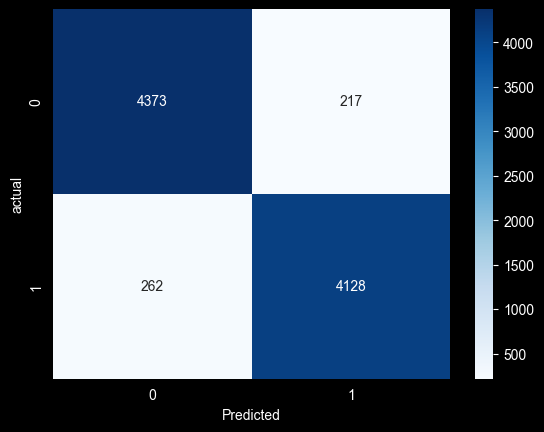

In [53]:
vectorizer = TfidfVectorizer(stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z]+\b', ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
model = LogisticRegression()
model.fit(X_train_vec,y_train_enc)
y_pred = model.predict(X_test_vec)
print("Accuracy: ", accuracy_score(y_test_enc, y_pred)*100)
accuracy = accuracy_score(y_test_enc, y_pred)*100;
metrics = {"accuracy": accuracy}
cm = confusion_matrix(y_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("actual")
plt.show()

In [54]:
#prediction_text = ["Jesus Clarifies shocking Return Will Be Strictly Limited To Carpentry Business"]
#new_text = vectorizer.transform(prediction_text)
#prediction_label = model.predict(new_text)
#print(prediction_label[0])

In [62]:
with open("models/model.pkl", "wb") as file:
    pickle.dump(model, file)
with open("models/vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)
with open("metrics.json", "w") as file:
    json.dump(metrics, file)